In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [ ]:
X, y = make_blobs(n_samples=500, centers=3, cluster_std=1.0,random_state=42)

In [ ]:
df = pd.DataFrame(X,columns = ['Feature_1','Feature_2'])

In [ ]:
df

,Feature_1,Feature_2
0,-5.730354,-7.583286
1,1.942992,1.918875
2,6.829682,1.164871
3,-2.901306,7.550771
4,5.841093,1.565094
...,...,...
495,-5.480272,-5.955476
496,-2.586299,9.355438
497,4.304094,3.642191
498,-7.402350,-5.831100


In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

In [ ]:
X_scaled

array([[-8.64585566e-01, -1.37893778e+00],
       [ 7.28634463e-01,  7.64529679e-02],
       [ 1.74325985e+00, -3.90333537e-02],
       [-2.77189136e-01,  9.39057802e-01],
       [ 1.53799870e+00,  2.22664638e-02],
       [ 1.46099313e+00, -4.63523872e-02],
       [-5.71658248e-01, -1.28594927e+00],
       [ 1.34474522e+00,  7.70743178e-02],
       [ 1.06691968e+00,  6.29615588e-02],
       [-1.23294101e+00, -1.26724012e+00],
       [ 1.15434196e+00, -8.08854249e-02],
       [ 4.47841237e-02,  1.03751674e+00],
       [ 2.47107048e-01,  8.64225938e-01],
       [-7.72413238e-02,  1.33714387e+00],
       [ 1.34875623e+00,  4.02646076e-01],
       [ 1.50835127e+00, -1.84606909e-01],
       [-2.10727049e-01,  1.31692118e+00],
       [-1.33632090e+00, -1.21266486e+00],
       [-1.08612501e+00, -1.10804290e+00],
       [-4.25484348e-01,  9.79999865e-01],
       [ 9.98204991e-01,  1.70995723e-01],
       [-1.52409123e-01,  8.63064598e-01],
       [ 1.40830092e+00,  1.32441374e-01],
       [-7.

In [ ]:
wcss = []
K_range = range(1,11)

In [ ]:
for k in K_range:
  Kmeans = KMeans(n_clusters=k,random_state=42)
  Kmeans.fit(X_scaled)
  wcss.append(Kmeans.inertia_)

In [ ]:
wcss

[999.9999999999992,
 313.31642287283603,
 31.613098744144406,
 26.682762313913198,
 22.63003629142292,
 18.96337312949171,
 17.403286654335698,
 15.71530301636485,
 13.909891755351829,
 12.928886002632517]

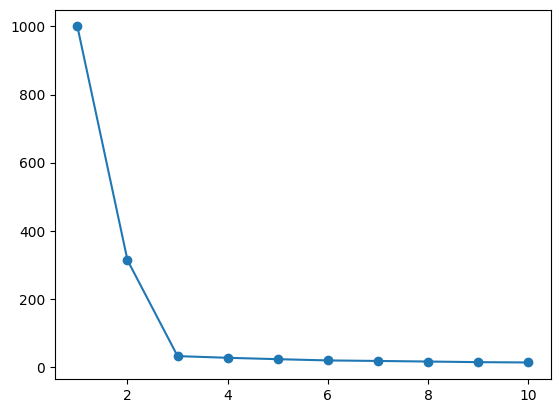

In [ ]:
plt.plot(K_range,wcss,marker='o')

In [ ]:
k_means_final = KMeans(n_clusters=3,random_state=42)
cluster_labels = k_means_final.fit_predict(X_scaled)

In [ ]:
cluster_labels

array([1, 0, 0, 2, 0, 0, 1, 0, 0, 1, 0, 2, 2, 2, 0, 0, 2, 1, 1, 2, 0, 2,
       0, 1, 1, 0, 0, 1, 1, 2, 0, 2, 2, 2, 0, 0, 0, 0, 1, 1, 0, 2, 2, 2,
       2, 0, 0, 0, 0, 1, 1, 2, 1, 1, 0, 2, 2, 1, 0, 1, 1, 2, 0, 1, 0, 1,
       0, 1, 2, 0, 0, 0, 0, 1, 2, 1, 2, 0, 2, 2, 1, 2, 0, 2, 1, 1, 1, 1,
       0, 2, 1, 0, 2, 0, 0, 1, 2, 2, 2, 1, 0, 2, 2, 1, 1, 2, 2, 1, 2, 1,
       1, 1, 1, 1, 1, 0, 2, 1, 0, 1, 2, 2, 0, 0, 1, 0, 2, 0, 1, 1, 1, 0,
       0, 1, 0, 1, 1, 1, 0, 2, 1, 1, 0, 0, 1, 1, 1, 2, 2, 2, 0, 1, 0, 0,
       2, 1, 2, 1, 0, 0, 1, 1, 2, 2, 1, 2, 2, 0, 1, 1, 1, 2, 2, 1, 1, 2,
       2, 0, 0, 0, 2, 1, 2, 2, 1, 1, 2, 0, 2, 1, 1, 1, 1, 1, 2, 0, 2, 2,
       1, 0, 2, 2, 1, 1, 0, 1, 0, 2, 2, 1, 1, 0, 1, 2, 2, 1, 2, 1, 2, 0,
       0, 2, 1, 2, 0, 2, 2, 1, 0, 0, 0, 0, 2, 1, 1, 1, 2, 0, 2, 0, 0, 0,
       2, 2, 1, 1, 0, 2, 2, 0, 2, 2, 2, 2, 0, 2, 1, 2, 1, 2, 2, 2, 1, 2,
       0, 0, 0, 2, 0, 0, 2, 2, 0, 1, 2, 2, 2, 2, 1, 1, 2, 0, 2, 2, 1, 2,
       0, 1, 0, 0, 1, 2, 2, 2, 1, 2, 1, 0, 0, 2, 0,

In [ ]:
df['cluster'] = cluster_labels

<Axes: xlabel='Feature_1', ylabel='Feature_2'>

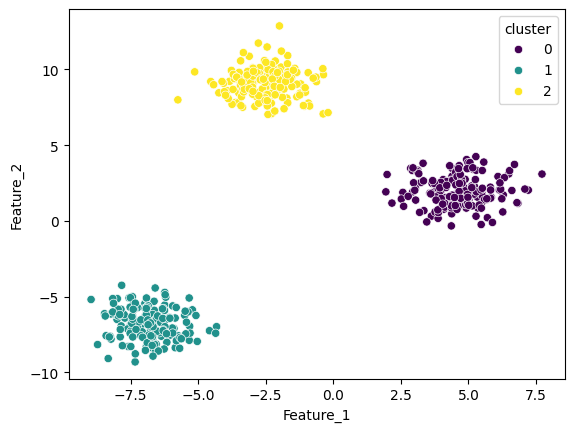

In [ ]:
sns.scatterplot(x=df['Feature_1'],
                y=df['Feature_2'],
                hue=df['cluster'],
                palette = 'viridis'
                )

DB SCAN

In [ ]:
from sklearn.datasets import make_moons

In [ ]:
X, y = make_moons(n_samples=500, noise=0.05, random_state=42)

In [ ]:
from sklearn.cluster import KMeans,DBSCAN

In [ ]:
df = pd.DataFrame(X,columns=['Feature_1','Feature_2'])

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

In [ ]:
kmeans = KMeans(n_clusters=2,random_state=42)
kmeans_labels = Kmeans.fit_predict(X_scaled)

In [ ]:
df['kmeans_clustering'] = kmeans_labels

<Axes: xlabel='Feature_1', ylabel='Feature_2'>

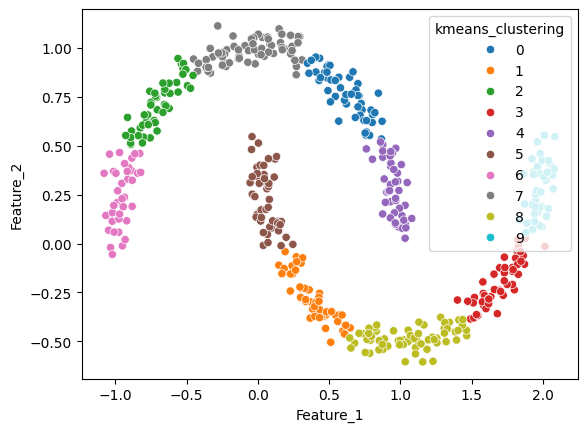

In [ ]:
sns.scatterplot(df,x = 'Feature_1',y = 'Feature_2',hue = 'kmeans_clustering',palette = 'tab10')

In [ ]:
dbscan = DBSCAN(eps = 0.5,min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)

In [ ]:
df['dbscan'] = dbscan_labels

<Axes: xlabel='Feature_1', ylabel='Feature_2'>

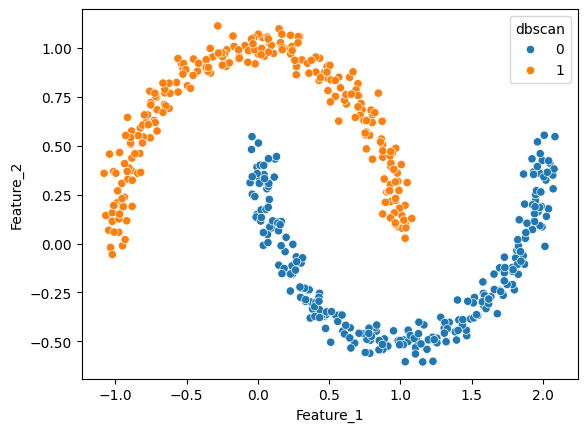

In [ ]:
sns.scatterplot(df,x = 'Feature_1',y='Feature_2',hue='dbscan',palette='tab10')